Rotor Radi + Road Distance

There are online websites to see what the LCoE was for EU countries.

For calculating Spot Price, we need WS, WS is the Wind Speed.

# Import Packages

In [986]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import yaml
from scipy.stats import weibull_min
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
from floris import FlorisModel
from floris.wind_data import WindRose
import floris as _floris_pkg

# Path to FLORIS built-in default GCH config
_FLORIS_DEFAULT_YAML = str(
    pathlib.Path(_floris_pkg.__file__).parent / 'default_inputs.yaml'
)
print('FLORIS', _floris_pkg.__version__, '-- default yaml found:', _FLORIS_DEFAULT_YAML)
import numpy as np
from scipy.optimize import differential_evolution

FLORIS 4.6.4 -- default yaml found: /home/lavender/Studies/Design of Wind Farms/.venv/lib/python3.12/site-packages/floris/default_inputs.yaml


In [987]:
import warnings
warnings.filterwarnings("ignore")

# Turbine Properties

In [988]:
tub_lib = r"/home/lavender/Studies/Design of Wind Farms/modules/floris/floris/turbine_library"
turbines = ["iea_3p4MW", "bar_bau_iea_3p3MW", "bar_bau_lsp_3p25MW"]
HH = 120

# Denmark Site

## Denmark Vars

In [989]:
d_ws = 0.17
d_ti = 12/100
d_fuel_cost = 9.5
d_line_freq = 50
d_standard_V = 220
d_interconnect_V = 100
d_rent = 15000
d_o_and_m = 0.012
d_discount = 3.6
d_life_time = 20
d_construction_time = 12		# Month

## Plotting Map

### Conversion to KM

In [990]:
lattitude_degree_to_km = 111
longitude_degree_to_km_at_55 = 63

### Helper Function

In [991]:
def get_ref(stri):
    # This is using the DMS format - Degree Minutes Seconds
    
	lattLB = 55 + (14/60) + (39.2/(3600))
	longLB = 9 + (00/60) + (41.3/(3600))

	latt_deg = float(stri.strip().split("°")[0])
	latt_min = float(stri.strip().split("'")[0].split("°")[1])
	latt_sec = float(stri.strip().split("\"")[0].split("°")[1].split("'")[1].replace("\\", ""))

	long_deg = float(stri.strip().split("N")[1].split("°")[0])
	long_min = float(stri.strip().split("N")[1].split("'")[0].split("°")[1])
	long_sec = float(stri.strip().split("N")[1].split("\"")[0].split("°")[1].split("'")[1].replace("\\", ""))

	latt = latt_deg + (latt_min/60) + (latt_sec/(3600))
	long = long_deg + (long_min/60) + (long_sec/(3600))
 
	latt = (latt - lattLB) * lattitude_degree_to_km
 
	long = (long - longLB) * longitude_degree_to_km_at_55

	return latt, long

In [992]:
def get_ref_WGS84(latt, long):
    # This is using the WGS84 lattitude/longitude form.
    
	lattLB = 55 + (14/60) + (39.2/(3600))
	longLB = 9 + (00/60) + (41.3/(3600))
 
	latt = (latt - lattLB) * lattitude_degree_to_km
 
	long = (long - longLB) * longitude_degree_to_km_at_55

	return latt, long

### Boundaries

In [993]:
# Left Bottom
lattLB, longLB = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")
# Right Bottom
lattRB, longRB = get_ref(r"55°14'53.8\"N 9°03'30.7\"E")
# Left Top
lattLT, longLT =  get_ref(r"55°15'48.1\"N 9°00'48.7\"E")
# Right Top
lattRT, longRT =  get_ref(r"55°15'41.7\"N 9°04'04.8\"E")

lattLB, lattRB, lattLT, lattRT, longLB, longRB, longLT, longRT

(0.0,
 0.4501666666671511,
 2.1244166666667326,
 1.9270833333336839,
 0.0,
 2.9645000000000046,
 0.12950000000000905,
 3.561249999999969)

### Roads

#### Kastrupvej

In [994]:
lat_k_start, lon_k_start = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")
lat_k_1, lon_k_1 = get_ref(r"55°14'49.0\"N 9°02'23.0\"E")
lat_k_2, lon_k_2 = get_ref(r"55°14'53.0\"N 9°02'60.0\"E")
lat_k_end, lon_k_end = get_ref(r"55°15'03.6\"N 9°03'38.0\"E")

#### Toftlundvej

In [995]:
lat_t_start, lon_t_start = get_ref(r"55°15'47.1\"N 9°02'07.5\"E")
lat_t_end, lon_t_end = get_ref(r"55°14'42.8\"N 9°02'24.7\"E")

#### Marbaekgardvej

In [996]:
lat_m_start, lon_m_start = get_ref(r"55°15'19.4\"N 9°02'15.0\"E")
lat_m_1, lon_m_1 = get_ref(r"55°15'18.0\"N 9°02'30.4\"E")
lat_m_2, lon_m_2 = get_ref(r"55°15'33.2\"N 9°02'35.7\"E")
lat_m_3, lon_m_3 = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")
lat_m_4, lon_m_4 = get_ref(r"55°15'46.0\"N 9°02'43.7\"E")
lat_m_5, lon_m_5 = get_ref(r"55°15'45.0\"N 9°02'50.1\"E")
lat_m_6, lon_m_6 = get_ref(r"55°15'45.6\"N 9°02'54.6\"E")
lat_m_7, lon_m_7 = get_ref(r"55°15'43.3\"N 9°03'10.5\"E")
lat_m_end, lon_m_end = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")

#### Udsigtsvejen

In [997]:
lat_u_start, lon_u_start = get_ref(r"55°15'41.7\"N 9°04'04.8\"E")
lat_u_1, lon_u_1 = get_ref(r"55°15'41.9\"N 9°03'46.7\"E")
lat_u_2, lon_u_2 = get_ref(r"55°15'49.5\"N 9°03'18.2\"E")
lat_u_end, lon_u_end = get_ref(r"55°15'54.6\"N 9°02'49.1\"E")

#### Stensvejen

In [998]:
lat_s_start, lon_s_start = get_ref(r"55°15'02.2\"N 9°02'19.4\"E")
lat_s_end, lon_s_end = get_ref(r"55°15'07.4\"N 9°00'48.6\"E")

#### Engvej

In [999]:
lat_e_start, lon_e_start = get_ref(r"55°15'48.1\"N 9°00'48.7\"E")
lat_e_1, lon_e_1 = get_ref(r"55°15'07.4\"N 9°00'48.6\"E")
lat_e_end, lon_e_end = get_ref(r"55°14'39.2\"N 9°00'41.3\"E")

### Town

#### Kastrup

In [1000]:
lat_k_town, lon_k_town = get_ref(r"55°15'46.7\"N 9°04'46.7\"E")

### Buildings

In [1001]:
builds = []

#### Preben Gad

In [1002]:
builds.append(get_ref_WGS84(55.26376264248587, 9.056352828928594))

#### Marbækgårdvej 1

In [1003]:
builds.append(get_ref_WGS84(55.26231259217023, 9.050049639108959))

#### Udsigtsvejen 16

In [1004]:
builds.append(get_ref_WGS84(55.2646173108904, 9.053834297505002))

#### Udsigtsvejen 15

In [1005]:
builds.append(get_ref_WGS84(55.26411229432016, 9.051162083724197))

#### Udsigtsvejen 18

In [1006]:
builds.append(get_ref_WGS84(55.26576740553818, 9.051293190948849))

#### Udsigtsvejen 17

In [1007]:
builds.append(get_ref_WGS84(55.264889460129645, 9.045758966509334))

#### Marbækvej 6


In [1008]:
builds.append(get_ref_WGS84(55.2671271658051, 9.044682957544456))

#### Marbækvej 5

In [1009]:
builds.append(get_ref_WGS84(55.26829141385979, 9.049309200476348))

#### Hinne van der Harst

In [1010]:
# builds.append(get_ref_WGS84(55.24516341841765, 9.001604423465745))

#### Kastrupvej 26

In [1011]:
builds.append(get_ref_WGS84(55.244789869056724, 9.018664063980859))

#### Kastrupvej 24

In [1012]:
builds.append(get_ref_WGS84(55.2442058697137, 9.013678153589987))

#### Feltvej 6

In [1013]:
builds.append(get_ref(r"55°15'34.3\"N 9°03'57.9\"E"))

#### Toftlundvej 2

In [1014]:
# builds.append(get_ref_WGS84(55.27063315298789, 9.032570918783033))

#### Henrik Beck

In [1015]:
builds.append(get_ref_WGS84(55.262889159277975, 9.059533065052847))

#### Udsigtsvejen 13


In [1016]:
builds.append(get_ref_WGS84(55.262144456274946, 9.060026613116126))

#### Random Building

In [1017]:
builds.append(get_ref_WGS84(55.25146667381516, 9.028779460002486))

#### Engvej 21

In [1018]:
builds.append(get_ref_WGS84(55.26772112772359, 9.014694124807043))

In [1019]:
len(builds)

15

### Existing Wind Turbines

#### Kastrupvej

In [1020]:
wts = []

wts.append(get_ref_WGS84(55.2518537387715, 9.067113095780657))
wts.append(get_ref_WGS84(55.25005608478371, 9.065860880416732))
wts.append(get_ref_WGS84(55.24838910327743, 9.064680783026962))
wts.append(get_ref_WGS84(55.24662865506457, 9.063393833038278))

wts.append(get_ref_WGS84(55.25122021158104, 9.070125865365986))
wts.append(get_ref_WGS84(55.24940653519977, 9.068889527809011))
wts.append(get_ref_WGS84(55.2476480890615, 9.067588117653926))
wts.append(get_ref_WGS84(55.24588890783806, 9.066452109190593))

### Plotting

#### Variables

In [1021]:
ROAD_BUFFER_KM = 0.015  # 15m in km

#### Boundaries

In [1022]:
# Boundary Polygon (LB → RB → RT → LT, clockwise)
boundary_x = [longLB, longRB, longRT, longLT]
boundary_y = [lattLB, lattRB, lattRT, lattLT]

#### Road Segments

In [1023]:
road_segments = [
    # Kastrupvej
    ((lon_k_start, lat_k_start), (lon_k_1, lat_k_1)),
    ((lon_k_1,     lat_k_1    ), (lon_k_2, lat_k_2)),
    ((lon_k_2,     lat_k_2    ), (lon_k_end, lat_k_end)),
    # Toftlundvej
    ((lon_t_start, lat_t_start), (lon_t_end, lat_t_end)),
    # Marbaekgardvej
    ((lon_m_start, lat_m_start), (lon_m_1, lat_m_1)),
    ((lon_m_1,     lat_m_1    ), (lon_m_2, lat_m_2)),
    ((lon_m_2,     lat_m_2    ), (lon_m_3, lat_m_3)),
    ((lon_m_4,     lat_m_4    ), (lon_m_5, lat_m_5)),
    ((lon_m_5,     lat_m_5    ), (lon_m_6, lat_m_6)),
    ((lon_m_6,     lat_m_6    ), (lon_m_7, lat_m_7)),
    ((lon_m_4,     lat_m_4    ), (lon_m_end, lat_m_end)),
    # Udsigtsvejen
    ((lon_u_start, lat_u_start), (lon_u_1, lat_u_1)),
    ((lon_u_1,     lat_u_1    ), (lon_u_2, lat_u_2)),
    ((lon_u_2,     lat_u_2    ), (lon_u_end, lat_u_end)),
    # Stensvejen
    ((lon_s_start, lat_s_start), (lon_s_end, lat_s_end)),
    # Engvej
    ((lon_e_start, lat_e_start), (lon_e_1, lat_e_1)),
    ((lon_e_1,     lat_e_1    ), (lon_e_end, lat_e_end)),
]

#### Road Buffer Function

In [1024]:
def road_buffer_polygon(x0, y0, x1, y1, width):
    """Returns the 4 corners of a rectangle buffering a line segment."""
    import numpy as np
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    # Perpendicular unit vector
    px, py = -dy / length, dx / length
    offset = width / 2
    return [
        (x0 + px * offset, y0 + py * offset),
        (x1 + px * offset, y1 + py * offset),
        (x1 - px * offset, y1 - py * offset),
        (x0 - px * offset, y0 - py * offset),
    ]

#### Field Boarders

In [1025]:
fb = []

fb.append(get_ref_WGS84(55.263378079208664, 9.013538798791178))
fb.append(get_ref_WGS84(55.26179918912272, 9.023299488092954))
fb.append(get_ref_WGS84(55.259586009260396, 9.013611349046208))
fb.append(get_ref_WGS84(55.259193935675405, 9.020673691208579))
fb.append(get_ref_WGS84(55.2595214708722, 9.0230302748183))
fb.append(get_ref_WGS84(55.259378271002554, 9.025777960420816))
fb.append(get_ref_WGS84(55.26158955844181, 9.025215304079365))
fb.append(get_ref_WGS84(55.26133286769302, 9.025996682092389))
fb.append(get_ref_WGS84(55.26408211153519, 9.026229682092394))
fb.append(get_ref_WGS84(55.262858338573665, 9.0165206820924))
fb.append(get_ref_WGS84(55.26297458335403, 9.025491682092403))
fb.append(get_ref_WGS84(55.263673866522346, 9.016592317674311))
fb.append(get_ref_WGS84(55.25932834020308, 9.017505682092377))
fb.append(get_ref_WGS84(55.259174200214076, 9.020072631023627))
fb.append(get_ref_WGS84(55.26226868149219, 9.020374153862859))
fb.append(get_ref_WGS84(55.26264444703107, 9.01778336389916))
fb.append(get_ref_WGS84(55.25756314091412, 9.013645153862841))
fb.append(get_ref_WGS84(55.25720245038016, 9.017287363899133))
fb.append(get_ref_WGS84(55.256221450983844, 9.017067363899129))
fb.append(get_ref_WGS84(55.25663427915377, 9.013682635062942))
fb.append(get_ref_WGS84(55.25227933900355, 9.013579761751688))
fb.append(get_ref_WGS84(55.252772510595804, 9.014885728317171))
fb.append(get_ref_WGS84(55.25369862479202, 9.021289363899083))
fb.append(get_ref_WGS84(55.254410107761316, 9.023465761751694))
fb.append(get_ref_WGS84(55.25402528015716, 9.027360728317186))
fb.append(get_ref_WGS84(55.25583022731078, 9.028793728719485))
fb.append(get_ref_WGS84(55.25610728445766, 9.028820364282486))
fb.append(get_ref_WGS84(55.25651058312273, 9.024429509541378))
fb.append(get_ref_WGS84(55.26062528271976, 9.028256682092394))
fb.append(get_ref_WGS84(55.256452568469896, 9.025560476688629))
fb.append(get_ref_WGS84(55.25670462338135, 9.022741077788233))
fb.append(get_ref_WGS84(55.25918641280878, 9.021083364301436))
fb.append(get_ref_WGS84(55.256852469712854, 9.020928317655349))
fb.append(get_ref_WGS84(55.25652775471802, 9.024627238377558))
fb.append(get_ref_WGS84(55.259386169237, 9.024882635465257))
fb.append(get_ref_WGS84(55.25618541151709, 9.028140602795677))
fb.append(get_ref_WGS84(55.26030105520822, 9.029186999883349))
fb.append(get_ref_WGS84(55.256087112765265, 9.02913068209239))
fb.append(get_ref_WGS84(55.25957099829968, 9.031465682092385))
fb.append(get_ref_WGS84(55.255880055548246, 9.031405999883319))
fb.append(get_ref_WGS84(55.26413663029794, 9.028381995441729))
fb.append(get_ref_WGS84(55.259911107076, 9.030403999481049))
fb.append(get_ref_WGS84(55.26419873631289, 9.030540835089983))
fb.append(get_ref_WGS84(55.264219612989415, 9.032889039844271))
fb.append(get_ref_WGS84(55.25065491000093, 9.038712578608001))
fb.append(get_ref_WGS84(55.255770584185186, 9.032449682092357))
fb.append(get_ref_WGS84(55.25509552695409, 9.033109317655345))
fb.append(get_ref_WGS84(55.253796055708506, 9.037872317655324))
fb.append(get_ref_WGS84(55.25285207203288, 9.041681856493883))
fb.append(get_ref_WGS84(55.252617108197704, 9.04269609273523))
fb.append(get_ref_WGS84(55.25121528398915, 9.048198153862828))
fb.append(get_ref_WGS84(55.25129210840144, 9.047859728317148))
fb.append(get_ref_WGS84(55.251047050818485, 9.048852635062875))
fb.append(get_ref_WGS84(55.25053705595912, 9.050874271047139))
fb.append(get_ref_WGS84(55.25024769984094, 9.051968331631807))
fb.append(get_ref_WGS84(55.24961122412278, 9.054430999480939))
fb.append(get_ref_WGS84(55.24943110868766, 9.055107270644779))
fb.append(get_ref_WGS84(55.248740706183014, 9.05707176175165))
fb.append(get_ref_WGS84(55.24828555772259, 9.058515940225304))
fb.append(get_ref_WGS84(55.2487046465304, 9.058633231584592))
fb.append(get_ref_WGS84(55.25078105083899, 9.05981499948098))
fb.append(get_ref_WGS84(55.250269514694274, 9.057995425026625))
fb.append(get_ref_WGS84(55.24951053473027, 9.012836302097487))
fb.append(get_ref_WGS84(55.2492163284551, 9.015688339837745))
fb.append(get_ref_WGS84(55.24902019407573, 9.017395292572216))
fb.append(get_ref_WGS84(55.24892447387547, 9.0184323152763))
fb.append(get_ref_WGS84(55.24878115454767, 9.019663006773676))
fb.append(get_ref_WGS84(55.24831953029172, 9.02418918568632))
fb.append(get_ref_WGS84(55.24821788573318, 9.024989437744052))
fb.append(get_ref_WGS84(55.24806169968701, 9.026402926432059))
fb.append(get_ref_WGS84(55.247302845722054, 9.028205999885529))
fb.append(get_ref_WGS84(55.24580125104239, 9.027815656609373))
fb.append(get_ref_WGS84(55.24897347126353, 9.02874256913812))
fb.append(get_ref_WGS84(55.248965928164225, 9.030773871735189))
fb.append(get_ref_WGS84(55.248965928164225, 9.033837367236718))
fb.append(get_ref_WGS84(55.24895633622263, 9.044116605337392))
fb.append(get_ref_WGS84(55.24979178168034, 9.046247711366332))
fb.append(get_ref_WGS84(55.25049830197436, 9.046995773069371))
fb.append(get_ref_WGS84(55.25139549996574, 9.038552359965397))
fb.append(get_ref_WGS84(55.25140467274515, 9.0406337541843))
fb.append(get_ref_WGS84(55.25189728172065, 9.016409448109773))
fb.append(get_ref_WGS84(55.251811220618244, 9.018160958747437))
fb.append(get_ref_WGS84(55.25164483529184, 9.02054663702977))
fb.append(get_ref_WGS84(55.25131780003252, 9.02660646116331))
fb.append(get_ref_WGS84(55.244250737695246, 9.011482661115275))
fb.append(get_ref_WGS84(55.24477501186283, 9.01728546202535))
fb.append(get_ref_WGS84(55.24535959255163, 9.023391898093454))
fb.append(get_ref_WGS84(55.24600560678458, 9.030114777493683))
fb.append(get_ref_WGS84(55.246319880172095, 9.033192906826937))
fb.append(get_ref_WGS84(55.24652939438348, 9.035321563430532))
fb.append(get_ref_WGS84(55.24695714915413, 9.03973201728221))
fb.append(get_ref_WGS84(55.24763805540208, 9.046485524851162))
fb.append(get_ref_WGS84(55.2478260615601, 9.048451545900498))
fb.append(get_ref_WGS84(55.248286613602474, 9.050957010448316))
fb.append(get_ref_WGS84(55.25915885833599, 9.032726486977777))
fb.append(get_ref_WGS84(55.25863610853423, 9.034523567033938))
fb.append(get_ref_WGS84(55.25821380403339, 9.03587348591767))
fb.append(get_ref_WGS84(55.25797248022116, 9.03680642946182))
fb.append(get_ref_WGS84(55.257572629278556, 9.042665116894664))
fb.append(get_ref_WGS84(55.25744442411859, 9.045159582974144))
fb.append(get_ref_WGS84(55.257369009120254, 9.045986660571753))
fb.append(get_ref_WGS84(55.257210637171696, 9.046807121570005))
fb.append(get_ref_WGS84(55.25707866006572, 9.047316601383432))
fb.append(get_ref_WGS84(55.25671289264315, 9.048236311680547))
fb.append(get_ref_WGS84(55.25616612064468, 9.04962580208081))
fb.append(get_ref_WGS84(55.25615480804112, 9.049817684088465))
fb.append(get_ref_WGS84(55.25584342283734, 9.051734628344061))
fb.append(get_ref_WGS84(55.25569258663375, 9.052654338656616))
fb.append(get_ref_WGS84(55.25546256032172, 9.054209244552972))
fb.append(get_ref_WGS84(55.25540222533073, 9.054566542084467))
fb.append(get_ref_WGS84(55.254757389378774, 9.05684927628772))
fb.append(get_ref_WGS84(55.254546212744025, 9.057610187672527))
fb.append(get_ref_WGS84(55.253003835214464, 9.06122947933416))
fb.append(get_ref_WGS84(55.25186370701055, 9.063664363800962))
fb.append(get_ref_WGS84(55.25540798131461, 9.037532295481142))
fb.append(get_ref_WGS84(55.25494632862662, 9.041759456936028))
fb.append(get_ref_WGS84(55.25401590108877, 9.04368106540857))
fb.append(get_ref_WGS84(55.25370710330228, 9.044351617663736))
fb.append(get_ref_WGS84(55.25300389147301, 9.045842925887026))
fb.append(get_ref_WGS84(55.252716488269876, 9.046572486739313))
fb.append(get_ref_WGS84(55.25251775079296, 9.047361056186139))
fb.append(get_ref_WGS84(55.25262170590054, 9.048407117713682))
fb.append(get_ref_WGS84(55.25297132517922, 9.050121459284552))
fb.append(get_ref_WGS84(55.25299946123608, 9.050583379140999))
fb.append(get_ref_WGS84(55.25311218386971, 9.052104952809133))
fb.append(get_ref_WGS84(55.253182197391546, 9.053303233638285))
fb.append(get_ref_WGS84(55.2489492215643, 9.035925594736396))
fb.append(get_ref_WGS84(55.25018304982121, 9.04815845711716))
fb.append(get_ref_WGS84(55.24939306385255, 9.049460121330727))
fb.append(get_ref_WGS84(55.25020204451423, 9.051236684056777))
fb.append(get_ref_WGS84(55.25038118718926, 9.05139879127014))
fb.append(get_ref_WGS84(55.249790956165654, 9.049857118587944))
fb.append(get_ref_WGS84(55.249217688250845, 9.048365070562902))
fb.append(get_ref_WGS84(55.2555435008887, 9.033276601201356))
fb.append(get_ref_WGS84(55.264108607028334, 9.025373286768398))
fb.append(get_ref_WGS84(55.264497236481404, 9.013682351522888))
fb.append(get_ref_WGS84(55.26445934034586, 9.014768666111596))
fb.append(get_ref_WGS84(55.26222072409856, 9.020559348085323))
fb.append(get_ref_WGS84(55.26418551001019, 9.020715932355472))
fb.append(get_ref_WGS84(55.26533606796102, 9.020869460549681))
fb.append(get_ref_WGS84(55.26423758322738, 9.034172048302294))
fb.append(get_ref_WGS84(55.26408396075054, 9.035172603634564))
fb.append(get_ref_WGS84(55.262703696505014, 9.035492611146793))
fb.append(get_ref_WGS84(55.25893475007203, 9.036506636801228))
fb.append(get_ref_WGS84(55.260523466859716, 9.038730131916617))
fb.append(get_ref_WGS84(55.2598119635145, 9.043536302127572))
fb.append(get_ref_WGS84(55.26026030957294, 9.04577690105154))
fb.append(get_ref_WGS84(55.26028954935754, 9.046358430543258))
fb.append(get_ref_WGS84(55.26031878912063, 9.048239849487048))
fb.append(get_ref_WGS84(55.259963028884584, 9.051091779940204))
fb.append(get_ref_WGS84(55.26217105766619, 9.052207342482957))
fb.append(get_ref_WGS84(55.26277933705035, 9.045476508688918))
fb.append(get_ref_WGS84(55.26252746122752, 9.047171769134632))
fb.append(get_ref_WGS84(55.2626603190034, 9.048483288677163))
fb.append(get_ref_WGS84(55.26255790784042, 9.049406209836722))
fb.append(get_ref_WGS84(55.261908811753464, 9.05338078055656))
fb.append(get_ref_WGS84(55.26180555679392, 9.054201376473408))
fb.append(get_ref_WGS84(55.25892832516542, 9.033509479163001))
fb.append(get_ref_WGS84(55.2529618128421, 9.016351526687206))
fb.append(get_ref_WGS84(55.25185601311282, 9.01704327120105))
fb.append(get_ref_WGS84(55.25198074991654, 9.023146700668205))
fb.append(get_ref_WGS84(55.25152705238807, 9.023353577122455))
fb.append(get_ref_WGS84(55.2516527538692, 9.021234827489986))
fb.append(get_ref_WGS84(55.25887838703052, 9.047619181879195))
fb.append(get_ref_WGS84(55.25814163346454, 9.050137202174618))
fb.append(get_ref_WGS84(55.25843719322199, 9.051550300131455))
fb.append(get_ref_WGS84(55.26156327367187, 9.039884487753524))
fb.append(get_ref_WGS84(55.263449231476514, 9.04275850751901))
fb.append(get_ref_WGS84(55.263935003358704, 9.043528159086737))
fb.append(get_ref_WGS84(55.26545313487896, 9.045277736345772))
fb.append(get_ref_WGS84(55.261380762765164, 9.041103908244152))
fb.append(get_ref_WGS84(55.25121959443652, 9.029075578241915))
fb.append(get_ref_WGS84(55.25207752492171, 9.029886077128559))
fb.append(get_ref_WGS84(55.252226879348385, 9.03088548928953))
fb.append(get_ref_WGS84(55.25209141838044, 9.032140848467339))
fb.append(get_ref_WGS84(55.25478894761439, 9.03422053681479))
fb.append(get_ref_WGS84(55.25089458066402, 9.033831153491723))
fb.append(get_ref_WGS84(55.2510266889164, 9.0313372460178))
fb.append(get_ref_WGS84(55.25922779364273, 9.055538834641853))
fb.append(get_ref_WGS84(55.260399353156, 9.06107211474652))
fb.append(get_ref_WGS84(55.26030290457672, 9.061523456290434))
fb.append(get_ref_WGS84(55.2618621279051, 9.061932484564608))
fb.append(get_ref_WGS84(55.259009689282784, 9.056408673842139))
fb.append(get_ref_WGS84(55.2630146878491, 9.057609051933003))
fb.append(get_ref_WGS84(55.263784664718784, 9.05484126848888))
fb.append(get_ref_WGS84(55.26200860999288, 9.053027948514249))
fb.append(get_ref_WGS84(55.2640268434764, 9.053621031847511))
fb.append(get_ref_WGS84(55.25395065621873, 9.059211816588933))
fb.append(get_ref_WGS84(55.25980755068798, 9.062498282003395))
fb.append(get_ref_WGS84(55.2593051636274, 9.064018293176174))
fb.append(get_ref_WGS84(55.258993452388395, 9.064963938389333))
fb.append(get_ref_WGS84(55.25303711642365, 9.061219710178927))
fb.append(get_ref_WGS84(55.252257339242966, 9.063067389619157))
fb.append(get_ref_WGS84(55.258736260274425, 9.067214090051877))
fb.append(get_ref_WGS84(55.26157599830298, 9.064793067834298))
fb.append(get_ref_WGS84(55.26157938483438, 9.067932906664897))
# fb.append(get_ref_WGS84(55.263378079208664, 9.013538798791178))


#### Lines

In [1026]:
lines = [
		[0,2,16,19,20,62,84],
		[0,135,136,11,9],
		[137,138,139,134,8,40,42,43,140,141,142,95],
		[0,9,15,14,1,6,7,28,36,41,38,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113],
		[2,12,13,3,31,4,34,5,7,29],
		[16,17,32,30,27,33,29,35,26,37,39,45,46,47,48,49,51,50,52,53,54,55,56,57,58],
		[62,63,64,65,66,67,68,69,72,73,74,75,76,77,51],
		[114,115,116,117,118,119,120,121,122,123,124,125,108,54],
		[44,78,79,48],
		[20,21,22,23,24,25,26],
		[20,80,81,82,83,44],
		[69,70,71],
		[84,85,86,87,71,87,88,89,90,91,92,93,56,61,60],
		[85,65],
		[80,63],
		[64,81],
		[66,82],
		[86,67],
		[68,83],
		[87,73],
		[88,74],
		[89,126],
		[76,91],
		[77,127,92],
		[132,128,131,129,130],
		[99,117],
		[49,116],
		[101,118],
		[9,11],
		[15,12],
		[14,13],
		[31,32],
		[28,35],
		[36,37],
		[41,42],
		[6,10,134],
		[38,39],
		[7,8],
		[1,4],
		[147,152],
		[45,133,157],
		[133,96],
		[43,94],
		[16,17,18,19],
		[96,143,144,145,146,147,148,149,150],
		[151,152,153,154,150,155,156],
		[159,158],
		[22,160,161],
		[160,162],
		[121,50],
		[52,122],
		[53,124],
		[123,106],
		[102,163,148],
		[163,164,165,155],
		[144,166,167,168,169],
		[166,170,167],
		[171,172,173,174,177],
		[175,174,177],
		[175,176],
		[111,179,180,181],
		[109,178,182,183],
		[107,156,184],
		[185,186],
		[187,188,189,190,193],
		[112,190],
		[192,193],
		[103,119],
		[105,121],
    ]

len(lines)

69

#### Actual Plotting

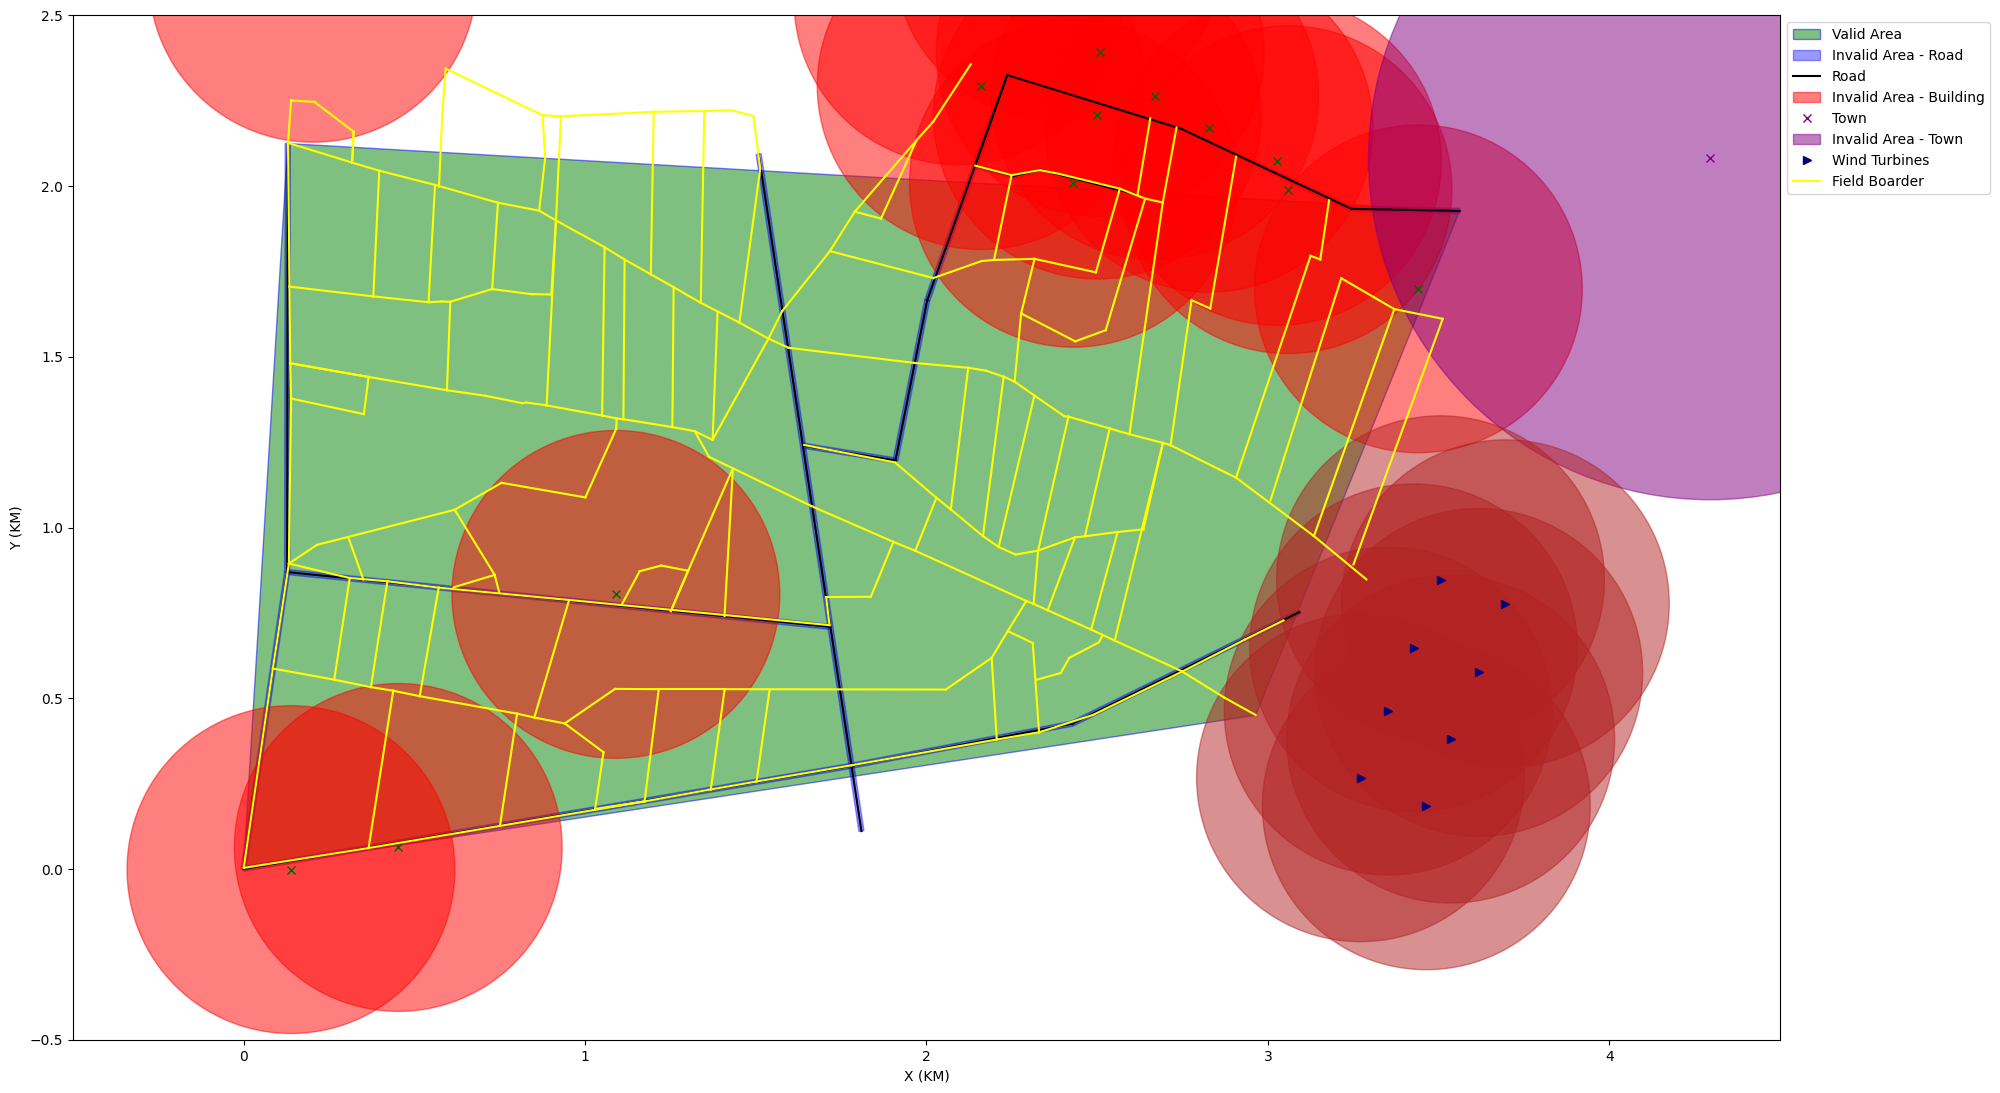

In [1027]:
fig, ax = plt.subplots(figsize=(20,12))

ax.add_patch(plt.Polygon(list(zip(boundary_x, boundary_y)),closed=True, facecolor='green', edgecolor='blue', alpha=0.5, label="Valid Area"))

# Draw road buffers + road lines
first_road = True
for (x0, y0), (x1, y1) in road_segments:
    buf = road_buffer_polygon(x0, y0, x1, y1, ROAD_BUFFER_KM)
    ax.add_patch(plt.Polygon(buf, closed=True, facecolor='blue', edgecolor='blue', alpha=0.4, label="Invalid Area - Road" if first_road else "_nolegend_"))
    ax.plot([x0, x1], [y0, y1], color='black', label="Road" if first_road else "_nolegend_")
    first_road = False

# Buildings
first_build = True
for lat, lon in builds:
    ax.plot(lon, lat, 'x', color='darkgreen')
    ax.add_patch(plt.Circle((lon, lat), radius=(HH * 4 / 1000), facecolor='red', edgecolor='red', alpha=0.5, label="Invalid Area - Building" if first_build else "_nolegend_"))
    first_build = False

# Towns
ax.plot(lon_k_town, lat_k_town, 'x', color='purple', label="Town")
ax.add_patch(plt.Circle((lon_k_town, lat_k_town), radius=(1), facecolor='purple', edgecolor='purple', alpha=0.5, label="Invalid Area - Town"))

# Wind Turbines
first_wt = True
for lat, lon in wts:
    ax.plot(lon, lat, '>', color='navy', label="Wind Turbines" if first_wt else "_nolegend_")
    ax.add_patch(plt.Circle((lon, lat), radius=(HH * 4 / 1000), facecolor='firebrick', edgecolor='firebrick', alpha=0.5, label="Invalid Area - Wind Turbine" if first_build else "_nolegend_"))
    first_wt = False

# first_fb = True
# for i, (lat, lon) in enumerate(fb):
#     ax.plot(lon, lat, '*', color='gold', markersize=10, label="Field Lines" if first_fb else "_nolegend_")
#     ax.annotate(str(i), xy=(lon, lat), xytext=(0, 8),
#                 textcoords='offset points', ha='center', fontsize=8)
#     first_fb = False

first_build = True
for line in lines:
	for l in range(len(line)-1):
		ax.plot((fb[line[l]][1], fb[line[l+1]][1]), (fb[line[l]][0], fb[line[l+1]][0]), color='yellow', label="Field Boarder" if first_build else "_nolegend_")
		first_build = False

ax.set_aspect('equal')
ax.autoscale()
ax.set_xlabel("X (KM)")
ax.set_ylabel("Y (KM)")
ax.set_xlim(-0.5,4.5)
ax.set_ylim(-0.5,2.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

## Setting Up Floris

### Wind Rose (Kastrup)

In [1028]:
# ===================================================================
# MODULE 1 -- Wind Rose (Kastrup, Site 1)
# ===================================================================
# Data from Table 2 / WindRose_Kastrup_FinalAssignment.xlsx

WD_BINS  = np.array([0,30,60,90,120,150,180,210,240,270,300,330], dtype=float)
WB_SCALE = np.array([9.785,8.284,8.721,9.633,10.114,8.340,
                      8.936,10.759,11.710,11.363,10.682,8.965])  # lambda [m/s]
WB_SHAPE = np.array([2.306,2.089,1.888,1.935,1.945,1.902,
                      1.909,1.910,1.968,2.049,2.064,1.928])       # k [-]
FREQ_WD  = np.array([14.71,6.09,6.16,8.17,9.58,6.05,
                      5.34,7.27,8.00,14.60,7.78,6.25]) / 100.0

# Wind-speed bins: cut-in to cut-out at 1 m/s resolution
WS_BINS   = np.arange(3.0, 26.0, 1.0)   # 23 bins
SITE1_TI  = d_ti      # turbulence intensity (Table 1)
WIND_SHEAR= d_ws      # shear exponent alpha (Table 1)

# Build joint freq table P(WD_i, WS_j) from per-sector Weibull distributions
freq_table = np.zeros((len(WD_BINS), len(WS_BINS)))
for i, (k, lam) in enumerate(zip(WB_SHAPE, WB_SCALE)):
    p_ws = weibull_min.pdf(WS_BINS, c=k, scale=lam) * 3.0  # bin width = 1 m/s
    p_ws /= p_ws.sum()   # renormalise (remove truncated tail)
    freq_table[i, :] = FREQ_WD[i] * p_ws

wind_rose = WindRose(
    wind_directions=WD_BINS,
    wind_speeds=WS_BINS,
    ti_table=SITE1_TI,
    freq_table=freq_table,
)
print(f'WindRose: {len(WD_BINS)} dirs x {len(WS_BINS)} speeds')
print(f'Frequency sum: {freq_table.sum():.6f}  (should be 1.0)')


WindRose: 12 dirs x 23 speeds
Frequency sum: 1.000000  (should be 1.0)


### Show WindRose

<PolarAxes: >

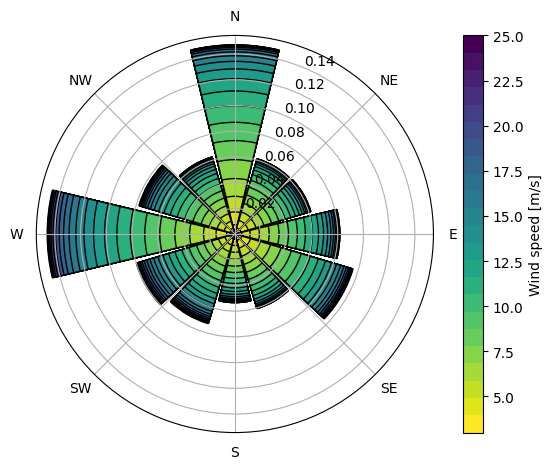

In [1029]:
wind_rose.plot()

## Actual Optimization

### Line Segment Forcing

#### Line Segments

In [1030]:
LINE_SEGMENTS = []

for line in lines:
    for i in range(len(line) - 1):
        p1 = (fb[line[i]][1], fb[line[i]][0])      # (lon, lat) = (x, y)
        p2 = (fb[line[i+1]][1], fb[line[i+1]][0])  # (lon, lat) = (x, y)
        LINE_SEGMENTS.append([p1, p2])

print(len(LINE_SEGMENTS))

# [print(i) for i in LINE_SEGMENTS]

237


#### No of Turbines

In [1031]:
N_TURBINES = 5

#### Line Constraint Penalty

In [1032]:
PENALTY_WEIGHT = 1e3   # increase if turbines keep drifting off lines

def _point_to_segment_dist_sq(px, py, x1, y1, x2, y2):
    """Squared distance from point (px, py) to segment (x1,y1)-(x2,y2)."""
    dx, dy = x2 - x1, y2 - y1
    seg_len_sq = dx * dx + dy * dy
    if seg_len_sq == 0:
        return (px - x1) ** 2 + (py - y1) ** 2
    t = max(0.0, min(1.0, ((px - x1) * dx + (py - y1) * dy) / seg_len_sq))
    cx, cy = x1 + t * dx, y1 + t * dy
    return (px - cx) ** 2 + (py - cy) ** 2


def min_dist_to_any_line(x, y):
    """Return the minimum squared distance from (x, y) to the nearest segment."""
    best = np.inf
    for (x1, y1), (x2, y2) in LINE_SEGMENTS:
        d = _point_to_segment_dist_sq(x, y, x1, y1, x2, y2)
        if d < best:
            best = d
    return best


def line_penalty(positions):
    """
    Total line-constraint penalty for all turbines.
    positions: list of (x, y) tuples
    """
    return sum(min_dist_to_any_line(x, y) for x, y in positions)

#### Boundary Constraint

In [1033]:
# Build the actual boundary polygon
boundary_polygon = Polygon(zip(boundary_x, boundary_y))

BOUNDARY_PENALTY_WEIGHT = 1e3

def boundary_penalty(positions):
    total = 0.0
    for x, y in positions:
        p = Point(x, y)
        if not boundary_polygon.contains(p):
            total += boundary_polygon.exterior.distance(p) ** 2
    return total

#### Exclusion Penalty

In [1034]:
EXCLUSION_PENALTY_WEIGHT = 1e4

# Precompute exclusion zones as (cx, cy, radius) in (lon, lat) = (x, y)
EXCLUSION_ZONES = []

BUILD_RADIUS = HH * 4 / 1000
for lat, lon in builds:
    EXCLUSION_ZONES.append((lon, lat, BUILD_RADIUS))

TOWN_RADIUS = 1.0
EXCLUSION_ZONES.append((lon_k_town, lat_k_town, TOWN_RADIUS))

WT_RADIUS = HH * 4 / 1000
for lat, lon in wts:
    EXCLUSION_ZONES.append((lon, lat, WT_RADIUS))


def exclusion_penalty(positions):
    total = 0.0
    for tx, ty in positions:
        for cx, cy, r in EXCLUSION_ZONES:
            dist = np.sqrt((tx - cx)**2 + (ty - cy)**2)
            if dist < r:
                total += (r - dist) ** 2   # penalty grows as turbine goes deeper in
    return total

#### Objective Function

In [1035]:
fmodel = FlorisModel(r"/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment6/gch.yaml")

def evaluate_layout(positions: list[tuple[float, float]]) -> float:
    x = []
    y = []
    for pos in positions:
        x.append(pos[0])
        y.append(pos[1])
    fmodel.set(layout_x=x,layout_y=y,wind_data=wind_rose,wind_shear=d_ws)
    fmodel.run()
    return(fmodel.get_farm_AEP()/1e9)

AEP_WEIGHT = 1e2

def _objective(flat_xy):
    positions = [(flat_xy[2 * i], flat_xy[2 * i + 1]) for i in range(N_TURBINES)]
    value = evaluate_layout(positions) * AEP_WEIGHT
    penalty  = 1e4 * line_penalty(positions)
    penalty += 1e4 * boundary_penalty(positions)
    penalty += EXCLUSION_PENALTY_WEIGHT * exclusion_penalty(positions)
    return -value + penalty

In [1036]:
X_MIN = min(longLB, longLT)
X_MAX = max(longRB, longRT)
Y_MIN = min(lattLB, lattRB)
Y_MAX = max(lattLT, lattRT)

X_MAX

3.561249999999969

In [1037]:
# ---------------------------------------------------------------------------
# 6. SEARCH BOUNDS
#    Set [x_min, x_max] and [y_min, y_max] to your study area.
# ---------------------------------------------------------------------------
X_MIN = min(longLB, longLT)
X_MAX = max(longRB, longRT)
Y_MIN = min(lattLB, lattRB)
Y_MAX = max(lattLT, lattRT)

bounds = []
for _ in range(N_TURBINES):
    bounds.append((X_MIN, X_MAX))  # x (longitude km)
    bounds.append((Y_MIN, Y_MAX))  # y (latitude km)


# ---------------------------------------------------------------------------
# 7. RUN THE OPTIMIZER
# ---------------------------------------------------------------------------
# def run_optimization(
#     n_turbines=N_TURBINES,
#     seed=42,
#     maxiter=1000,
#     popsize=15,
#     tol=1e-2,
# ):
#     global N_TURBINES
#     N_TURBINES = n_turbines

#     result = differential_evolution(
#         _objective,
#         bounds=bounds,
#         seed=seed,
#         maxiter=maxiter,
#         popsize=popsize,
#         tol=tol,
#         mutation=(0.5, 1.0),
#         recombination=0.7,
#         polish=True,          # local refinement after global search
#         disp=True,            # print progress
#     )

#     best_positions = [(result.x[2 * i], result.x[2 * i + 1]) for i in range(N_TURBINES)]
#     best_value = -result.fun   # un-negate (penalty should be ~0 at solution)

#     print("\n=== Optimization complete ===")
#     print(f"Best objective value : {best_value:.4f}")
#     print(f"Constraint penalty   : {line_penalty(best_positions):.6f}  (should be ~0)")
#     print("Turbine positions:")
#     for i, (x, y) in enumerate(best_positions):
#         print(f"  Turbine {i}: x={x:.3f}, y={y:.3f}")

#     return best_positions, best_value


from scipy.optimize import minimize
import numpy as np

def run_optimization(n_turbines=N_TURBINES, seed=42, maxiter=5000):
    global N_TURBINES
    N_TURBINES = n_turbines

    # Rebuild bounds for the correct number of turbines
    bounds = []
    for _ in range(N_TURBINES):
        bounds.append((X_MIN, X_MAX))
        bounds.append((Y_MIN, Y_MAX))

    rng = np.random.default_rng(seed)
    x0 = rng.uniform(
        low= [b[0] for b in bounds],
        high=[b[1] for b in bounds],
    )

    result = minimize(
        _objective,
        x0,
        method="Nelder-Mead",
        options={"maxiter": maxiter, "disp": True, "xatol": 1e-3, "fatol": 1e-3},
    )

    best_positions = [(result.x[2 * i], result.x[2 * i + 1]) for i in range(N_TURBINES)]
    best_value = -result.fun

    print("\n=== Optimization complete ===")
    print(f"Best AEP             : {best_value/AEP_WEIGHT:.2f} GWh/yr")
    print(f"Constraint penalty   : {line_penalty(best_positions):.8f}  (should be ~0)")
    for i, (x, y) in enumerate(best_positions):
        print(f"  Turbine {i}: x={x:.4f} km, y={y:.4f} km")

    return x0, best_positions, best_value

x0_start, positions, aep = run_optimization(maxiter=5000, n_turbines=8)


# # ---------------------------------------------------------------------------
# # 8. ENTRY POINT
# # ---------------------------------------------------------------------------
# if __name__ == "__main__":
#     positions, value = run_optimization(n_turbines=N_TURBINES)

Optimization terminated successfully.
         Current function value: -5135.064590
         Iterations: 1499
         Function evaluations: 2127

=== Optimization complete ===
Best AEP             : 51.35 GWh/yr
Constraint penalty   : 0.00017549  (should be ~0)
  Turbine 0: x=2.6411 km, y=0.9906 km
  Turbine 1: x=3.0085 km, y=1.4452 km
  Turbine 2: x=0.4075 km, y=2.0409 km
  Turbine 3: x=2.7411 km, y=1.4842 km
  Turbine 4: x=0.4326 km, y=1.0076 km
  Turbine 5: x=1.3484 km, y=1.9454 km
  Turbine 6: x=2.2662 km, y=1.5304 km
  Turbine 7: x=1.7994 km, y=0.5221 km


In [1038]:
aep

np.float64(5135.064590142761)

In [1039]:
print("\n=== Start position (random seed) ===")
for i in range(N_TURBINES):
    print(f"  Turbine {i}: x={x0_start[2*i]:.4f} km, y={x0_start[2*i+1]:.4f} km")

print("\n=== Best positions found ===")
for i, (x, y) in enumerate(positions):
    print(f"  Turbine {i}: x={x:.4f} km, y={y:.4f} km")

print(f"\nBest AEP: {aep/1e6:.2f} MWh/yr")


=== Start position (random seed) ===
  Turbine 0: x=2.7563 km, y=0.9324 km
  Turbine 1: x=3.0577 km, y=1.4815 km
  Turbine 2: x=0.3354 km, y=2.0726 km
  Turbine 3: x=2.7106 km, y=1.6699 km
  Turbine 4: x=0.4562 km, y=0.9568 km
  Turbine 5: x=1.3205 km, y=1.9688 km
  Turbine 6: x=2.2930 km, y=1.7479 km
  Turbine 7: x=1.5791 km, y=0.4827 km

=== Best positions found ===
  Turbine 0: x=2.6411 km, y=0.9906 km
  Turbine 1: x=3.0085 km, y=1.4452 km
  Turbine 2: x=0.4075 km, y=2.0409 km
  Turbine 3: x=2.7411 km, y=1.4842 km
  Turbine 4: x=0.4326 km, y=1.0076 km
  Turbine 5: x=1.3484 km, y=1.9454 km
  Turbine 6: x=2.2662 km, y=1.5304 km
  Turbine 7: x=1.7994 km, y=0.5221 km

Best AEP: 0.01 MWh/yr


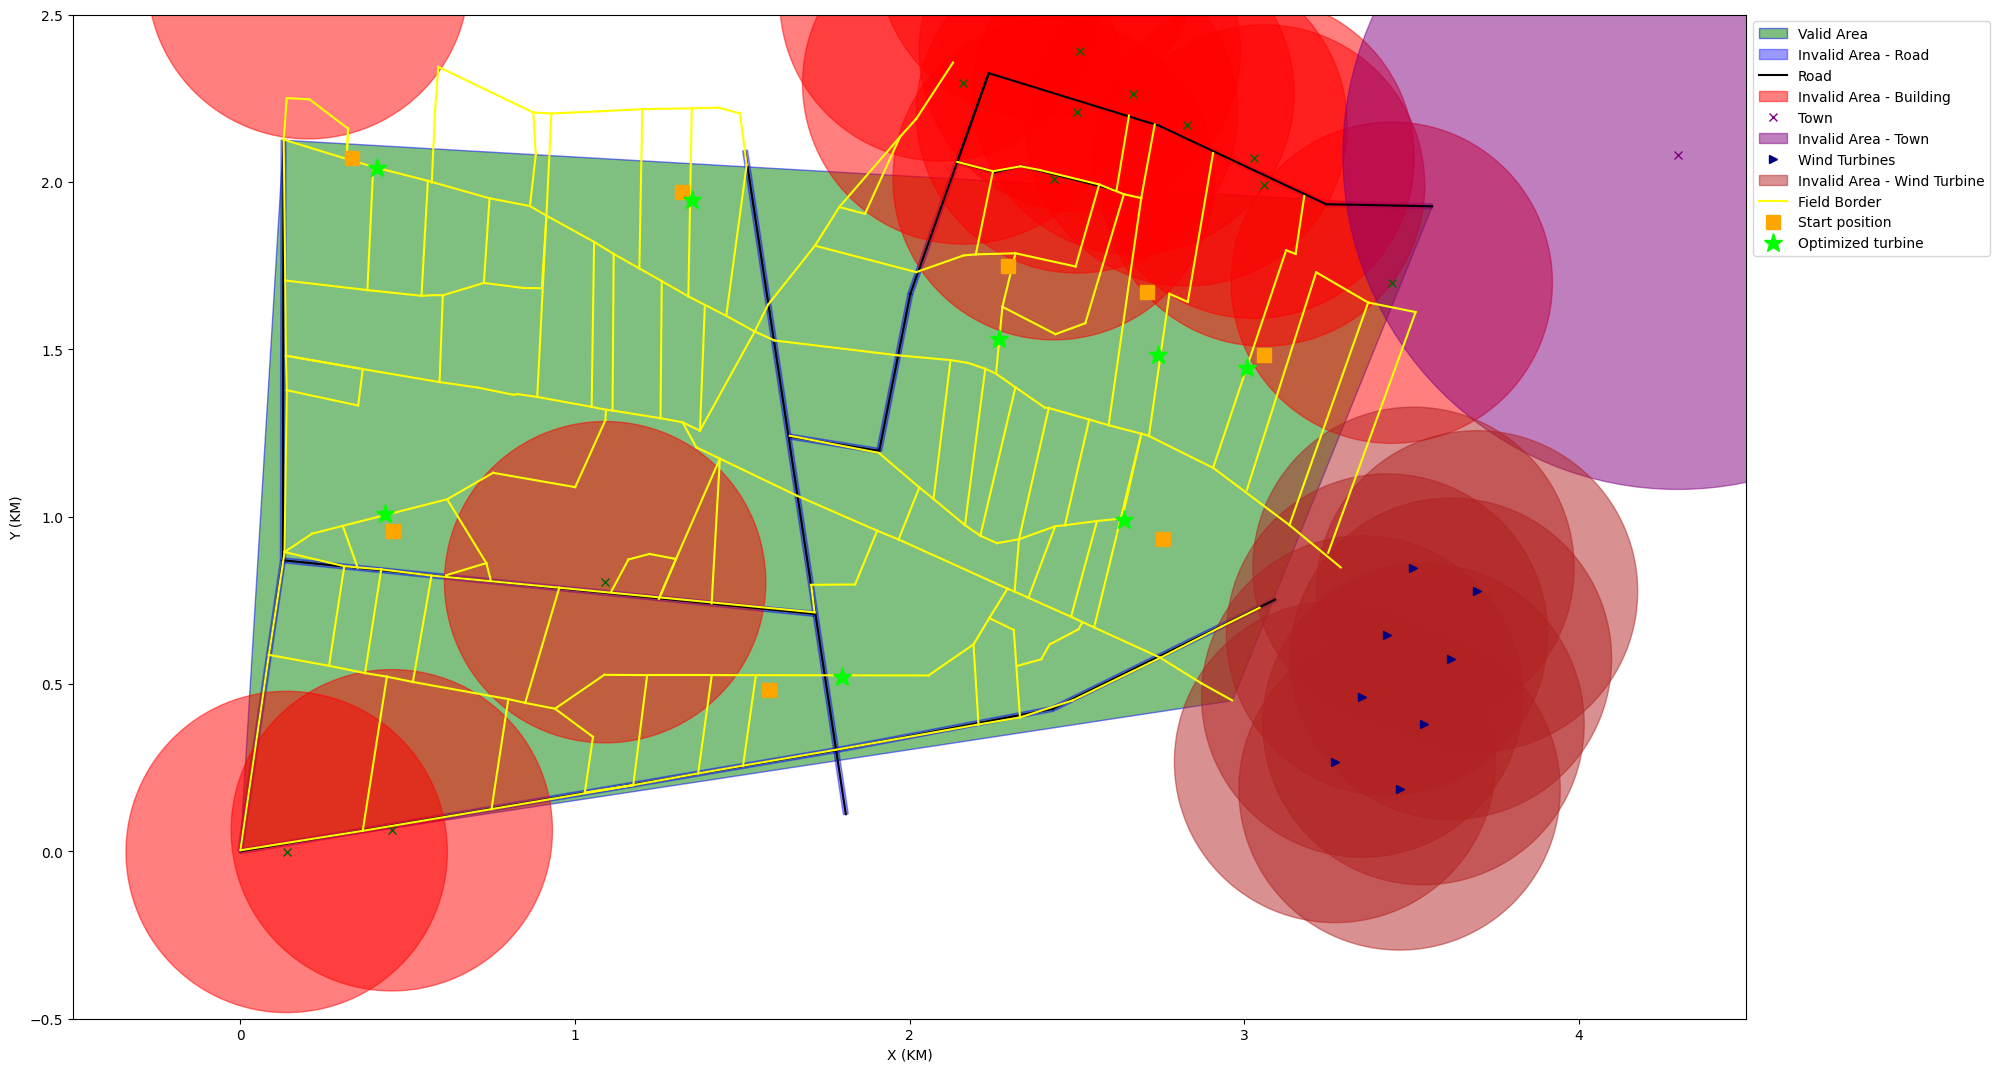

In [1040]:
fig, ax = plt.subplots(figsize=(20,12))

ax.add_patch(plt.Polygon(list(zip(boundary_x, boundary_y)),closed=True, facecolor='green', edgecolor='blue', alpha=0.5, label="Valid Area"))

first_road = True
for (x0, y0), (x1, y1) in road_segments:
    buf = road_buffer_polygon(x0, y0, x1, y1, ROAD_BUFFER_KM)
    ax.add_patch(plt.Polygon(buf, closed=True, facecolor='blue', edgecolor='blue', alpha=0.4, label="Invalid Area - Road" if first_road else "_nolegend_"))
    ax.plot([x0, x1], [y0, y1], color='black', label="Road" if first_road else "_nolegend_")
    first_road = False

first_build = True
for lat, lon in builds:
    ax.plot(lon, lat, 'x', color='darkgreen')
    ax.add_patch(plt.Circle((lon, lat), radius=(HH * 4 / 1000), facecolor='red', edgecolor='red', alpha=0.5, label="Invalid Area - Building" if first_build else "_nolegend_"))
    first_build = False

ax.plot(lon_k_town, lat_k_town, 'x', color='purple', label="Town")
ax.add_patch(plt.Circle((lon_k_town, lat_k_town), radius=(1), facecolor='purple', edgecolor='purple', alpha=0.5, label="Invalid Area - Town"))

first_wt = True
for lat, lon in wts:
    ax.plot(lon, lat, '>', color='navy', label="Wind Turbines" if first_wt else "_nolegend_")
    ax.add_patch(plt.Circle((lon, lat), radius=(HH * 4 / 1000), facecolor='firebrick', edgecolor='firebrick', alpha=0.5, label="Invalid Area - Wind Turbine" if first_wt else "_nolegend_"))
    first_wt = False

first_line = True
for line in lines:
    for l in range(len(line)-1):
        ax.plot((fb[line[l]][1], fb[line[l+1]][1]), (fb[line[l]][0], fb[line[l+1]][0]), color='yellow', label="Field Border" if first_line else "_nolegend_")
        first_line = False

# --- Start positions ---
first_start = True
for i in range(N_TURBINES):
    ax.plot(x0_start[2*i], x0_start[2*i+1], 's', color='orange', markersize=10,
            label="Start position" if first_start else "_nolegend_")
    first_start = False

# --- Best positions ---
first_best = True
for x, y in positions:
    ax.plot(x, y, '*', color='lime', markersize=14,
            label="Optimized turbine" if first_best else "_nolegend_")
    first_best = False

ax.set_aspect('equal')
ax.set_xlabel("X (KM)")
ax.set_ylabel("Y (KM)")
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 2.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()